In [1]:
!pip install Biopython

     |████████████████████████████████| 2.3MB 9.0MB/s 


In [17]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D, Embedding, LSTM, Dense, Bidirectional, TimeDistributed

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [3]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [4]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [5]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [18]:
print(len(bind), len(unbind))

1400090 1400090


##### Reverse complement

In [19]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [21]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [22]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [23]:
bind_dict = {"seq":bind_fb, "label":bind_label}
unbind_dict = {"seq":unbind_fb, "label":unbind_label}

In [24]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [25]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [27]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [28]:
x = new_df.seq
y = new_df.label

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [30]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [31]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_t = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:05:44.037409


### CNN + RNN model

In [54]:
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=7, strides=1, padding='valid', activation='relu', input_shape=(20, 5)))
model.add(MaxPooling1D(pool_size=3, strides=1, padding='valid'))
# model.add(Flatten())

model.add(LSTM(32, return_sequences=True))
model.add(LSTM(32))
#model.add(Bidirectional(LSTM(64, return_sequences=True)))
#model.add(Bidirectional(LSTM(64)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [55]:
model.summary()

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_10 (Conv1D)           (None, 14, 64)            2304      
_________________________________________________________________
max_pooling1d_8 (MaxPooling1 (None, 12, 64)            0         
_________________________________________________________________
lstm_15 (LSTM)               (None, 12, 32)            12416     
_________________________________________________________________
lstm_16 (LSTM)               (None, 32)                8320      
_________________________________________________________________
dense_14 (Dense)             (None, 32)                1056      
_________________________________________________________________
dropout_7 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_15 (Dense)             (None, 2)               

In [56]:
history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 730s 6ms/step - loss: 0.3541 - accuracy: 0.8452 - val_loss: 0.3216 - val_accuracy: 0.8612
Epoch 2/10
112008/112008 [==============================] - 703s 6ms/step - loss: 0.3223 - accuracy: 0.8613 - val_loss: 0.3198 - val_accuracy: 0.8627
Epoch 3/10
112008/112008 [==============================] - 694s 6ms/step - loss: 0.3185 - accuracy: 0.8629 - val_loss: 0.3188 - val_accuracy: 0.8623
Epoch 4/10
112008/112008 [==============================] - 686s 6ms/step - loss: 0.3168 - accuracy: 0.8636 - val_loss: 0.3153 - val_accuracy: 0.8638
Epoch 5/10
112008/112008 [==============================] - 701s 6ms/step - loss: 0.3152 - accuracy: 0.8642 - val_loss: 0.3151 - val_accuracy: 0.8638
Epoch 6/10
112008/112008 [==============================] - 689s 6ms/step - loss: 0.3154 - accuracy: 0.8641 - val_loss: 0.3142 - val_accuracy: 0.8639
Epoch 7/10
112008/112008 [==============================] - 691s 6ms/step - loss: 0.3143 - accuracy:

##### Evaluation

Accuracy

In [57]:
score = model.evaluate(x_t, y_t)
print("score = " + str(round(score[1],2)))

35003/35003 [==============================] - 101s 3ms/step - loss: 0.3144 - accuracy: 0.8636
score = 0.86


loss-epoch curve

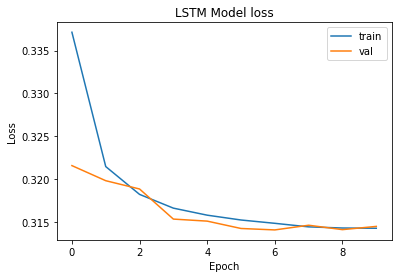

In [58]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [59]:
probs = model.predict(x_t)[:,1]

In [61]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)

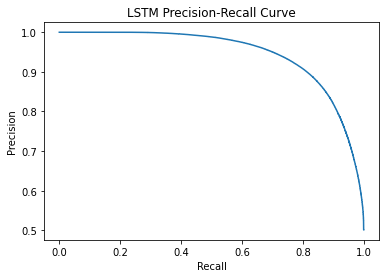

In [62]:
plt.plot(recall, precision)

plt.title('LSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC Curve, AUC

In [63]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

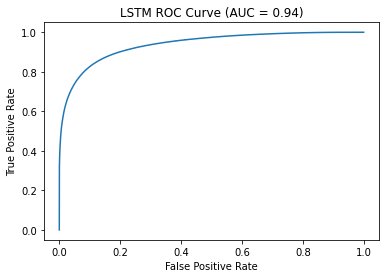

In [64]:
plt.plot(fpr, tpr)
plt.title('LSTM ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()